In [1]:
import numpy as np
import sys 
sys.path.append(r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\modules\RCWA")
import matplotlib.pyplot as plt
import torch
from d2M_function_final2 import RCWAForward
import hdf5storage
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [19]:
%matplotlib ipympl

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

rcwa = RCWAForward(
    air_path=r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\光栅\material_lambda_nk\Air_lambda_n_k.mat",
    si_path=r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\光栅\material_lambda_nk\Si_lambda_n_k.mat",
    theta_deg=45.0,
    phi_deg=0.0,
    device=device,
    dtype=None,
    number_of_layers=10,
    lambda_start_nm=480.0,
    lambda_stop_nm=720.0,
    lambda_step_nm=2.0
)

thickness_label = 0.197
Lambda_label = 0.855
TCD_label = 0.405
angle_trap_label = 86.0

ms_pred = rcwa(thickness_label, Lambda_label, TCD_label, angle_trap_label)   # [121, 16]
print(ms_pred.shape)

# 归一化：除以 M00 最大值
ms_pred_norm = ms_pred / ms_pred[:, 0].abs().max()

torch.Size([121, 16])


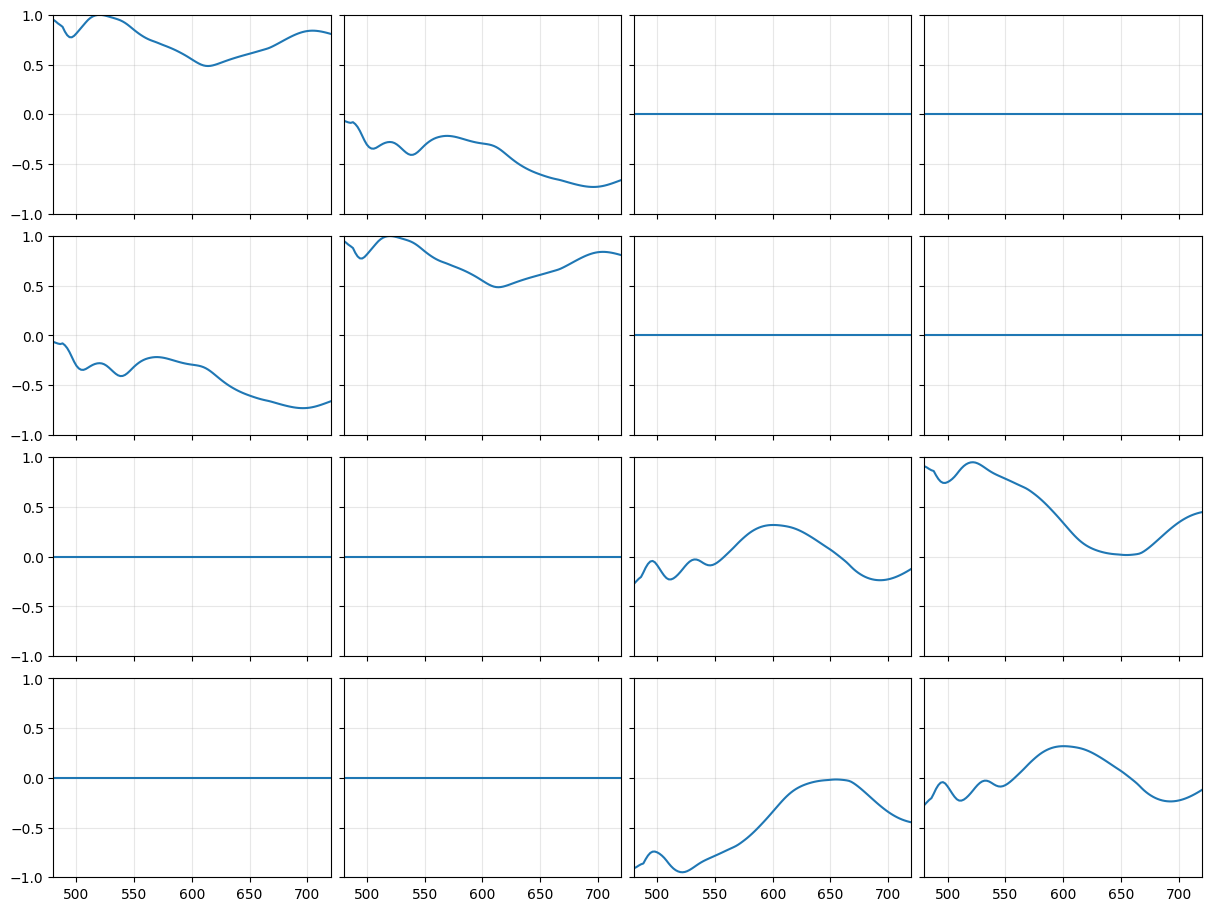

In [3]:
ms_pred_norm = ms_pred / ms_pred[:, 0].abs().max()

x = np.arange(480, 721, 2)

fig, axes = plt.subplots(4, 4, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
for j in range(4):          
    for k in range(4):
        ax = axes[j, k]
        ax.plot(x, ms_pred_norm[:, j*4 + k].detach().cpu().numpy())
        ax.grid(True, alpha=0.3)
        plt.ylim(-1, 1)
        plt.xlim(480, 720)
plt.show()

## 载入ms label 进行对比

In [5]:
ms_label = np.loadtxt(
    r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\Dataset\Iout_label\Muller_list.txt",
    delimiter=','
)

ms_label_norm = ms_label / np.abs(ms_label[:, 0]).max()
print(ms_label.shape)
print(ms_label_norm.shape)

(121, 16)
(121, 16)


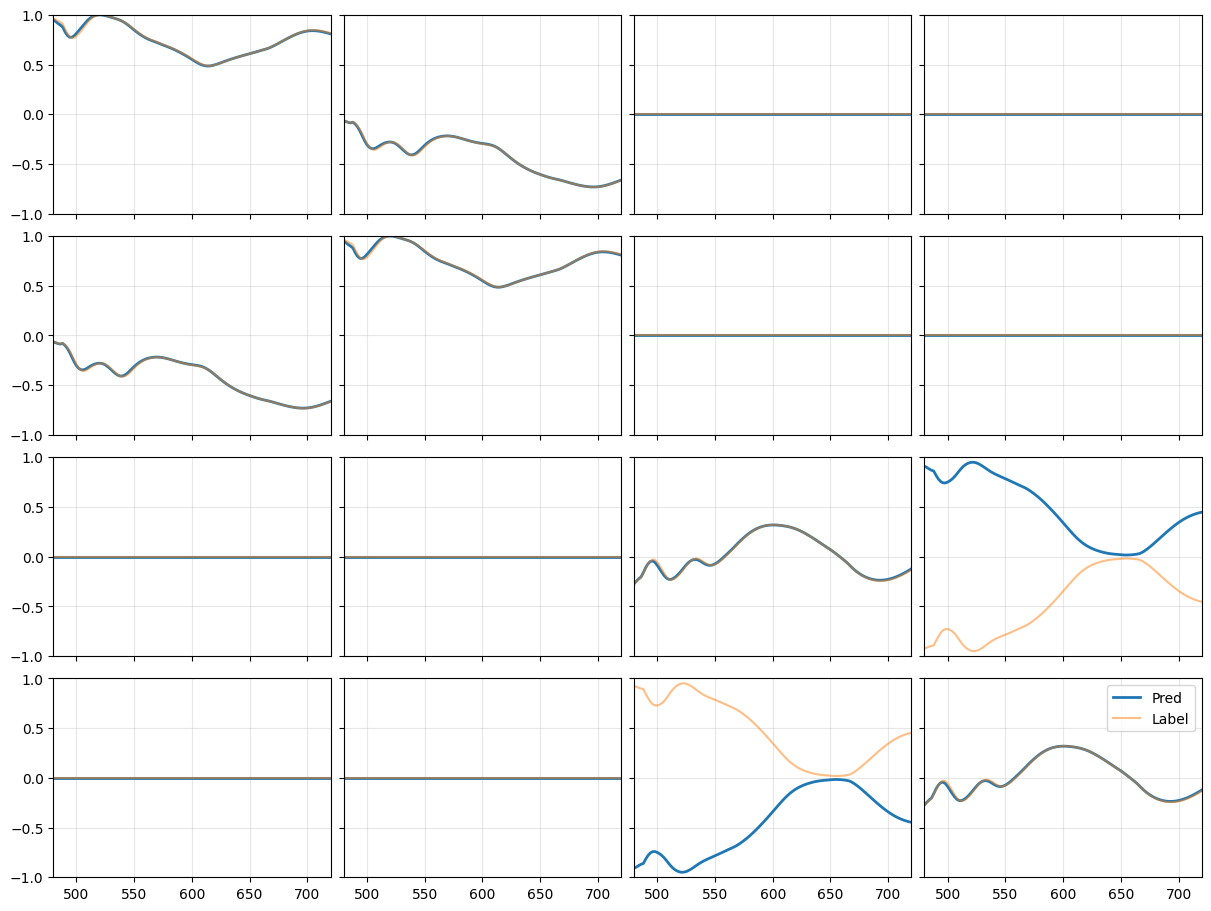

In [6]:
x = np.arange(480, 721, 2)

fig, axes = plt.subplots(4, 4, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
for j in range(4):          
    for k in range(4):
        ax = axes[j, k]
        ax.plot(x, ms_pred_norm[:, j*4 + k].detach().cpu().numpy(), label="Pred", linewidth=2)
        ax.plot(x, ms_label_norm[:, j*4 + k], alpha=0.5, label="Label")
        ax.grid(True, alpha=0.3)
        plt.ylim(-1, 1)
        plt.xlim(480, 720)

plt.legend()
plt.show()

# 准备工作

In [7]:
def compute_Iout_vectorized(ms, Sencoder, Spec, Mdecoder, *, eps=1e-12):
    if not isinstance(ms, torch.Tensor):
        raise TypeError("ms must be a torch.Tensor")
    ref_dev, ref_dtype = ms.device, ms.dtype
    Sencoder = torch.as_tensor(Sencoder, device=ref_dev, dtype=ref_dtype)
    Spec     = torch.as_tensor(Spec,     device=ref_dev, dtype=ref_dtype)
    Mdecoder = torch.as_tensor(Mdecoder, device=ref_dev, dtype=ref_dtype)
    ms = ms.unsqueeze(0).unsqueeze(1).unsqueeze(1)
    N = ms.shape[0]
    Ms_expanded = ms.expand(N, 256, 256, -1, -1, -1)  # [N,256,256,121,4,4]
    S_out = torch.matmul(Ms_expanded, Sencoder)       # [N,256,256,121,4,1]
    S_out = S_out.squeeze(-1).permute(0, 1, 2, 4, 3)  # [N,256,256,4,121]
    S_out = S_out.reshape(N, 256, 256, -1)            # [N,256,256,484]
    S_out_spec = S_out * Spec.squeeze()               # [N,256,256,484]
    I_out = (Mdecoder * S_out_spec).sum(dim=-1)       # [N,256,256]
    eps_t = torch.as_tensor(eps, device=ref_dev, dtype=ref_dtype)
    denom = I_out.view(N, -1).max(dim=1, keepdim=True)[0].view(N, 1, 1).clamp_min(eps_t)
    I_out = I_out / denom
    return I_out

In [8]:
def show_triptych(I_out_real, I_out_pred, *, cmap_res='magma',
                  cbar_size='3%', cbar_pad=0.05):
    """并排画 I_real / I_pred / |residual|，每个子图右侧加等高瘦色条。"""
    I_r = I_out_real.detach().cpu().squeeze().numpy()
    I_p = I_out_pred.detach().cpu().squeeze().numpy()
    res = np.abs(I_r - I_p)

    # 统一颜色范围（不然两个图看起来不对等）
    vmin = min(I_r.min(), I_p.min())
    vmax = max(I_r.max(), I_p.max())

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].set_title('I_out real')
    axes[1].set_title('I_out pred')
    axes[2].set_title('residual')

    ims = []
    ims.append(axes[0].imshow(I_r))
    ims.append(axes[1].imshow(I_p))
    ims.append(axes[2].imshow(res))

    for ax, im in zip(axes, ims):
        ax.set_axis_off()
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=cbar_size, pad=cbar_pad)
        fig.colorbar(im, cax=cax)

    plt.show()

In [9]:
M_path = r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\Dataset\Iout_label\M_decoder.mat"
M_dict = hdf5storage.loadmat(M_path)
M_Decoder = M_dict["M"]
M_Decoder = torch.from_numpy(M_Decoder)
print(M_Decoder.shape)
M_Decoder = M_Decoder.permute(0, 1, 3, 2)
M_Decoder = M_Decoder.reshape(256, 256, 4*121)
print(M_Decoder.shape)

Sencoder_path = r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\Dataset\Iout_label\S_encoder.mat"
Sencoder_dict = hdf5storage.loadmat(Sencoder_path)
S_Encoder = Sencoder_dict["S"] 
S_Encoder = torch.from_numpy(S_Encoder)
print(S_Encoder.shape)
S_Encoder = S_Encoder.unsqueeze(4).unsqueeze(0)
print(S_Encoder.shape)

Spec_path = r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\Dataset\Iout_label\spec.mat"
Spec_dict = hdf5storage.loadmat(Spec_path)
Spec = Spec_dict["Spec1"]
Spec = np.array(Spec, dtype=np.float64)
Spec = torch.from_numpy(Spec)
Spec = Spec.T
# Spec = Spec[:, 15:136]
print(Spec.shape)

torch.Size([256, 256, 121, 4])
torch.Size([256, 256, 484])
torch.Size([256, 256, 121, 4])
torch.Size([1, 256, 256, 121, 4, 1])
torch.Size([1, 484])


## Iout_real

torch.Size([256, 256])
torch.Size([1, 256, 256])


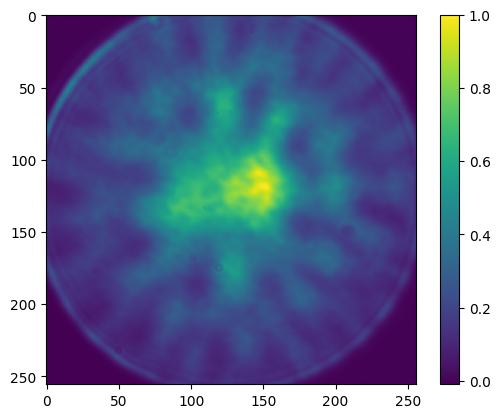

tensor([[[-0.0040, -0.0024, -0.0033,  ..., -0.0014, -0.0012, -0.0022],
         [-0.0021, -0.0030, -0.0023,  ..., -0.0003,  0.0002,  0.0002],
         [-0.0034, -0.0027, -0.0034,  ..., -0.0013, -0.0015, -0.0012],
         ...,
         [-0.0073, -0.0071, -0.0073,  ..., -0.0012, -0.0014, -0.0018],
         [-0.0094, -0.0085, -0.0089,  ..., -0.0028, -0.0020, -0.0016],
         [-0.0080, -0.0078, -0.0079,  ..., -0.0024, -0.0026, -0.0020]]],
       device='cuda:0')


In [10]:
I_path = r"F:\Seafile\Research\Nonlocal\New_Mueller\AllinOne\2025_I2parameters\case7光栅重启\Dataset\Iout_label\I_phi0.mat"
I_dict = hdf5storage.loadmat(I_path)
Iout_0 = I_dict["I"]
Iout_0 = torch.from_numpy(Iout_0)
print(Iout_0.shape)
I_out_real = Iout_0.to(device).float().unsqueeze(0)
print(I_out_real.shape)

plt.figure()
plt.imshow(I_out_real.cpu().squeeze())
plt.colorbar()
plt.show()

print(I_out_real)

In [11]:
# 3) 定义“可优化输入参数”
# ----------------------------
thickness = torch.nn.Parameter(torch.tensor(0.197, device=device, dtype=torch.float32))
Lambda    = torch.nn.Parameter(torch.tensor(0.855, device=device, dtype=torch.float32))
TCD       = torch.nn.Parameter(torch.tensor(0.405, device=device, dtype=torch.float32))
angle     = torch.nn.Parameter(torch.tensor(86.0,  device=device, dtype=torch.float32))

ms_pred = rcwa(thickness_label, Lambda, TCD, angle)   # [121, 16]
print(ms_pred.shape)
ms_pred = ms_pred.reshape(121, 4, 4)
print(ms_pred.shape)
I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
# 数据项
loss = torch.mean(torch.abs(I_out_pred - I_out_real))
loss.backward()
print(loss.item())

print("thickness.grad =", thickness.grad)
print("Lambda.grad    =", Lambda.grad)
print("TCD.grad       =", TCD.grad)
print("angle.grad     =", angle.grad)

torch.Size([121, 16])
torch.Size([121, 4, 4])
0.014735846780240536
thickness.grad = None
Lambda.grad    = tensor(0.0019, device='cuda:0')
TCD.grad       = tensor(-0.1298, device='cuda:0')
angle.grad     = tensor(0.0009, device='cuda:0')


In [11]:
print(I_out_pred)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0',
       grad_fn=<DivBackward0>)


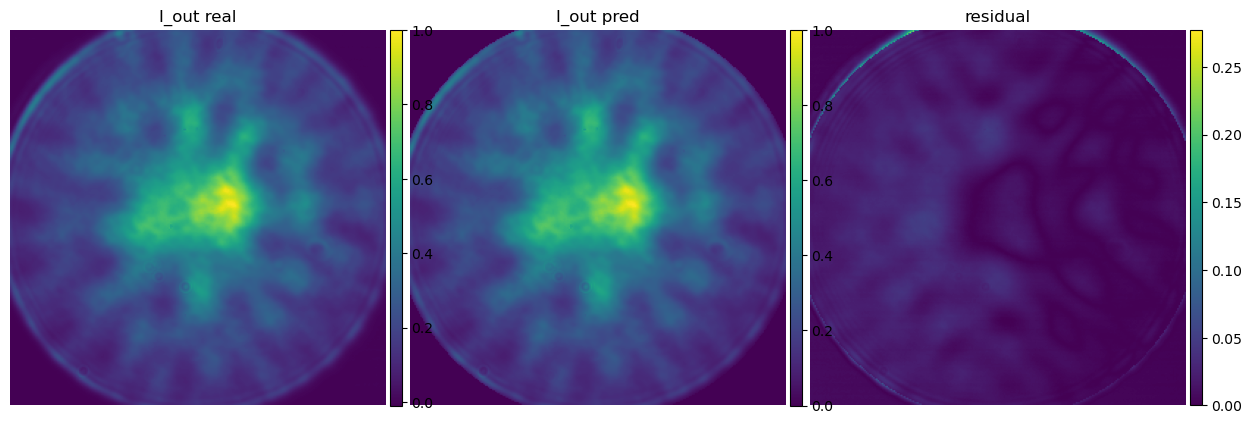

In [12]:
show_triptych(I_out_real, I_out_pred)

In [12]:
mask = make_circle_mask(
    radius=128,
    center_x=128,
    center_y=128,
    H=256,
    W=256,
    device=device,
    dtype=rcwa.rdtype
)

# 3) 定义“可优化输入参数”
# ----------------------------
thickness = torch.nn.Parameter(torch.tensor(0.197, device=device, dtype=torch.float32))
Lambda    = torch.nn.Parameter(torch.tensor(0.855, device=device, dtype=torch.float32))
TCD       = torch.nn.Parameter(torch.tensor(0.405, device=device, dtype=torch.float32))
angle     = torch.nn.Parameter(torch.tensor(86.0,  device=device, dtype=torch.float32))

ms_pred = rcwa(thickness_label, Lambda, TCD, angle)   # [121, 16]
print(ms_pred.shape)
ms_pred = ms_pred.reshape(121, 4, 4)
print(ms_pred.shape)
I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
I_out_pred_masked = I_out_pred * mask.unsqueeze(0)

I_out_real_masked = I_out_real* mask.unsqueeze(0)

show_triptych(I_out_real_masked, I_out_pred_masked)

NameError: name 'make_circle_mask' is not defined

In [13]:
# 3) 定义“可优化输入参数”
# ----------------------------
thickness = torch.nn.Parameter(torch.tensor(0.1978, device=device, dtype=torch.float32))
Lambda    = torch.nn.Parameter(torch.tensor(0.8618, device=device, dtype=torch.float32))
TCD       = torch.nn.Parameter(torch.tensor(0.4053, device=device, dtype=torch.float32))
angle     = torch.nn.Parameter(torch.tensor(83.6,  device=device, dtype=torch.float32))

ms_pred = rcwa(thickness_label, Lambda, TCD, angle)   # [121, 16]
print(ms_pred.shape)
ms_pred = ms_pred.reshape(121, 4, 4)
print(ms_pred.shape)
I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
# 数据项
loss = torch.mean(torch.abs(I_out_pred - I_out_real))
loss.backward()
print(loss.item())


torch.Size([121, 16])
torch.Size([121, 4, 4])
0.012680867686867714


In [14]:
# 3) 定义“可优化输入参数”
# ----------------------------
thickness = torch.nn.Parameter(torch.tensor(0.1980, device=device, dtype=torch.float32))
Lambda    = torch.nn.Parameter(torch.tensor(0.8640, device=device, dtype=torch.float32))
TCD       = torch.nn.Parameter(torch.tensor(0.4050, device=device, dtype=torch.float32))
angle     = torch.nn.Parameter(torch.tensor(84.0,  device=device, dtype=torch.float32))

ms_pred = rcwa(thickness_label, Lambda, TCD, angle)   # [121, 16]
print(ms_pred.shape)
ms_pred = ms_pred.reshape(121, 4, 4)
print(ms_pred.shape)
I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
# 数据项
loss = torch.mean(torch.abs(I_out_pred - I_out_real))
loss.backward()
print(loss.item())

torch.Size([121, 16])
torch.Size([121, 4, 4])
0.013101207092404366


# step1 sobol 双parameters 粗扫

In [16]:
import numpy as np
import torch

# -----------------------------
# circle mask
# -----------------------------
def make_circle_mask(radius, center_x, center_y, *, H=256, W=256, device="cpu", dtype=torch.float32):
    y = torch.arange(1, H + 1, device=device, dtype=dtype)
    x = torch.arange(1, W + 1, device=device, dtype=dtype)
    Y, X = torch.meshgrid(y, x, indexing="ij")
    distance = torch.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    mask = (distance <= radius).to(dtype)
    return mask


# -----------------------------
# masked MAE
# pred,label: [1,256,256]
# mask: [256,256]
# -----------------------------
def masked_mae(pred, label, eps=1e-12):
    loss = ((pred - label) ** 2).sum()
    return loss


# -----------------------------
# parameter range
# ±13 nm = ±0.013 um
# -----------------------------
thickness_center = 0.197
Lambda_center = 0.855

thickness_min = thickness_center - 0.013
thickness_max = thickness_center + 0.013

Lambda_min = Lambda_center - 0.013
Lambda_max = Lambda_center + 0.013

TCD_fixed = 0.405
angle_fixed = 86.0

# -----------------------------
# sobol setting
# -----------------------------
n_sobol = 64
topK = 5

sobol = torch.quasirandom.SobolEngine(dimension=2, scramble=True)
sobol_unit = sobol.draw(n_sobol).to(device=device, dtype=rcwa.rdtype)

thickness_cache = thickness_min + (thickness_max - thickness_min) * sobol_unit[:, 0]
Lambda_cache    = Lambda_min    + (Lambda_max    - Lambda_min)    * sobol_unit[:, 1]

# -----------------------------
# build mask
# 这里把参数写成你实验里真实用的
# 先给一个常见示例，之后你可以改
# -----------------------------
mask = make_circle_mask(
    radius=120,
    center_x=128,
    center_y=128,
    H=256,
    W=256,
    device=device,
    dtype=rcwa.rdtype
)

# label 也先做 mask
I_out_real_masked = I_out_real * mask.unsqueeze(0)

# -----------------------------
# scan
# -----------------------------
loss_list = []
record_list = []

for i in range(n_sobol):
    th = thickness_cache[i]
    lm = Lambda_cache[i]

    ms_pred = rcwa(th, lm, TCD_fixed, angle_fixed)   # [121,16]
    ms_pred = ms_pred.reshape(121, 4, 4)

    I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
    I_out_pred_masked = I_out_pred * mask.unsqueeze(0)

    loss = masked_mae(I_out_pred_masked, I_out_real_masked, mask)

    loss_list.append(loss.item())
    record_list.append([th.item(), lm.item(), loss.item()])

    print(f"[{i+1:02d}/{n_sobol}] thickness={th.item():.6f}, Lambda={lm.item():.6f}, loss={loss.item():.6e}")

# -----------------------------
# save all results
# columns: thickness, Lambda, loss
# -----------------------------
record_array = np.array(record_list, dtype=np.float64)
# np.save("sobol_scan_thickness_lambda_pm13nm.npy", record_array)

# # 也可以顺手另存成 npz
# np.savez(
#     "sobol_scan_thickness_lambda_pm13nm.npz",
#     thickness=record_array[:, 0],
#     Lambda=record_array[:, 1],
#     loss=record_array[:, 2],
# )

print(record_array.shape)

# -----------------------------
# topK
# -----------------------------
loss_tensor = torch.tensor(loss_list)
top_vals, top_idx = torch.topk(loss_tensor, k=topK, largest=False)

print("\nTopK results:")
for rank in range(topK):
    idx = int(top_idx[rank].item())
    th, lm, ls = record_list[idx]
    print(f"top{rank+1}: idx={idx}, thickness={th:.6f}, Lambda={lm:.6f}, loss={ls:.6e}")

[01/64] thickness=0.193942, Lambda=0.859508, loss=1.610452e-02
[02/64] thickness=0.199794, Lambda=0.844021, loss=1.765335e-02
[03/64] thickness=0.206623, Lambda=0.867152, loss=2.224887e-02
[04/64] thickness=0.187742, Lambda=0.849326, loss=1.947122e-02
[05/64] thickness=0.184267, Lambda=0.863949, loss=2.276015e-02
[06/64] thickness=0.209267, Lambda=0.852524, loss=2.470987e-02
[07/64] thickness=0.203295, Lambda=0.855393, loss=1.965537e-02
[08/64] thickness=0.191273, Lambda=0.848129, loss=1.697941e-02
[09/64] thickness=0.193616, Lambda=0.865558, loss=1.670279e-02
[10/64] thickness=0.200736, Lambda=0.850984, loss=1.795221e-02
[11/64] thickness=0.206949, Lambda=0.861116, loss=2.251463e-02
[12/64] thickness=0.186800, Lambda=0.842375, loss=1.979676e-02
[13/64] thickness=0.190288, Lambda=0.856985, loss=1.801135e-02
[14/64] thickness=0.204267, Lambda=0.846474, loss=2.071768e-02
[15/64] thickness=0.197273, Lambda=0.862344, loss=1.610346e-02
[16/64] thickness=0.196273, Lambda=0.854166, loss=1.573

torch.Size([1, 256, 256])
torch.Size([1, 256, 256])


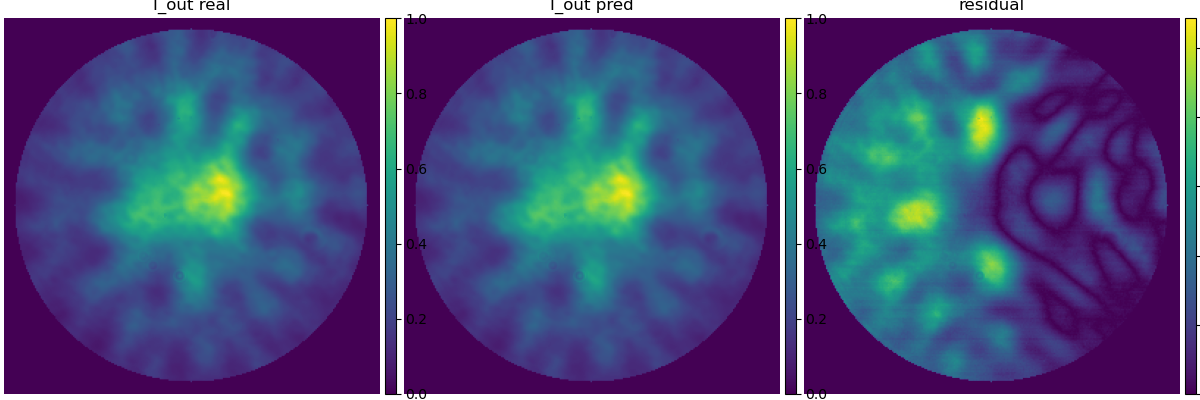

In [22]:
I_out_real_masked = I_out_real * mask.unsqueeze(0)
print(I_out_real_masked.shape)
I_out_pred_masked = I_out_pred * mask.unsqueeze(0)
print(I_out_pred_masked.shape)

show_triptych(I_out_real_masked, I_out_pred_masked)

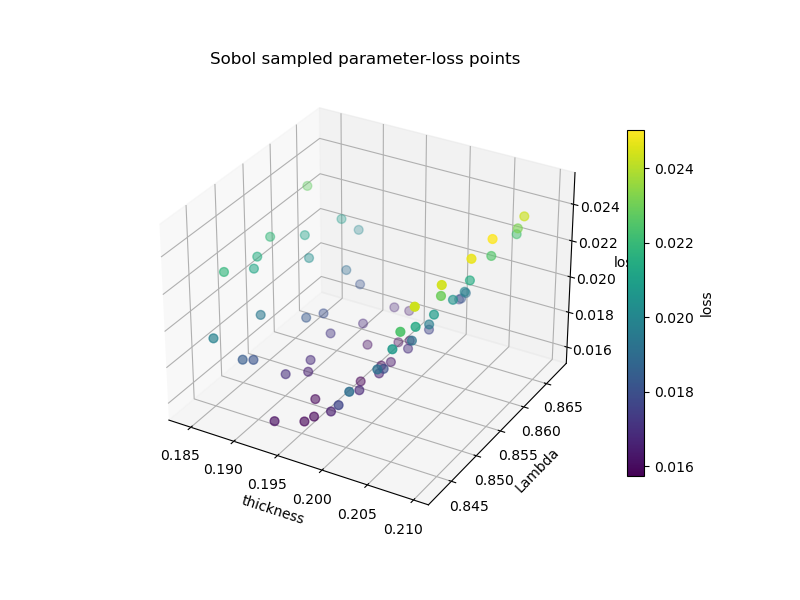

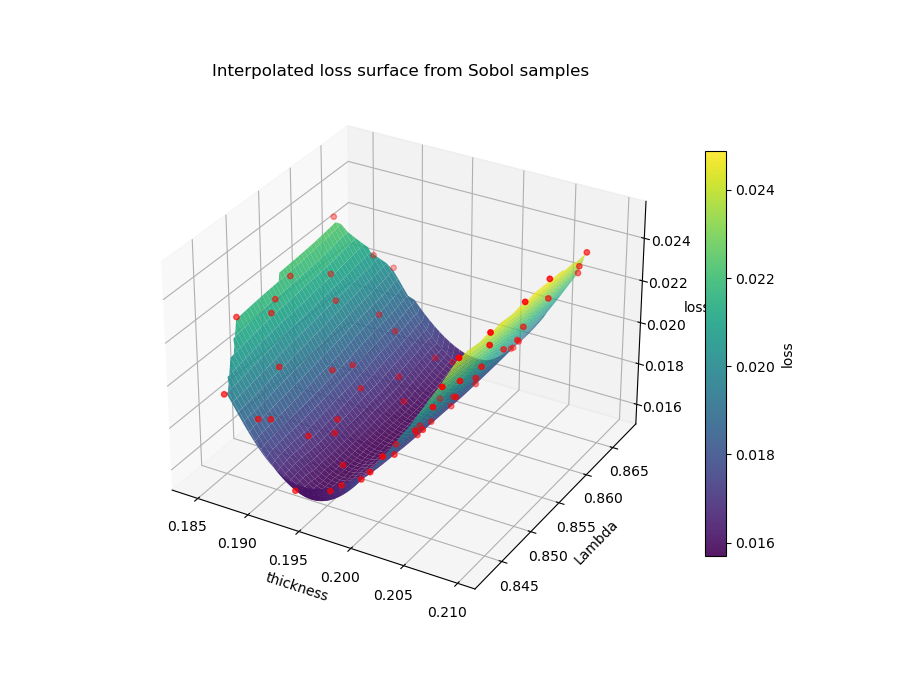

In [20]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np

# 直接使用你现有的结果
# record_array[:, 0] = thickness
# record_array[:, 1] = Lambda
# record_array[:, 2] = loss

# -----------------------------
# 1) 先画真实采样点的 3D scatter
# -----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    record_array[:, 0],
    record_array[:, 1],
    record_array[:, 2],
    c=record_array[:, 2],
    s=40
)

ax.set_xlabel("thickness")
ax.set_ylabel("Lambda")
ax.set_zlabel("loss")
ax.set_title("Sobol sampled parameter-loss points")
fig.colorbar(sc, ax=ax, shrink=0.75, label="loss")
plt.show()


# -----------------------------
# 2) 插值成 3D surface
# -----------------------------
grid_thickness = np.linspace(record_array[:, 0].min(), record_array[:, 0].max(), 100)
grid_lambda    = np.linspace(record_array[:, 1].min(), record_array[:, 1].max(), 100)
TT, LL = np.meshgrid(grid_thickness, grid_lambda)

ZZ = griddata(
    points=(record_array[:, 0], record_array[:, 1]),
    values=record_array[:, 2],
    xi=(TT, LL),
    method='cubic'   # 如果报错或有很多空洞，可改成 'linear'
)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(TT, LL, ZZ, cmap='viridis', alpha=0.9, linewidth=0)
ax.scatter(record_array[:, 0], record_array[:, 1], record_array[:, 2], c='r', s=15)

ax.set_xlabel("thickness")
ax.set_ylabel("Lambda")
ax.set_zlabel("loss")
ax.set_title("Interpolated loss surface from Sobol samples")
fig.colorbar(surf, ax=ax, shrink=0.75, label="loss")
plt.show()

# step2 4parameters tuning

In [23]:
# ------------------------------------------------
# step2: top1 -> joint optimize 4 params
# params: thickness, Lambda, TCD, s=cot(angle)
# ------------------------------------------------

def cotd_torch(x_deg):
    return 1.0 / torch.tan(torch.deg2rad(x_deg))

def angle_from_s(s):
    # s = cot(angle), angle in degree
    return torch.rad2deg(torch.atan2(torch.ones_like(s), s))

def to_raw(x, lo, hi, eps=1e-6):
    x = torch.as_tensor(x, device=device, dtype=rcwa.rdtype)
    lo = torch.as_tensor(lo, device=device, dtype=rcwa.rdtype)
    hi = torch.as_tensor(hi, device=device, dtype=rcwa.rdtype)
    p = (x - lo) / (hi - lo)
    p = p.clamp(eps, 1 - eps)
    return torch.log(p / (1 - p))

def from_raw(raw, lo, hi):
    lo = torch.as_tensor(lo, device=raw.device, dtype=raw.dtype)
    hi = torch.as_tensor(hi, device=raw.device, dtype=raw.dtype)
    return lo + (hi - lo) * torch.sigmoid(raw)

def masked_mae(pred, label, mask, eps=1e-12):
    diff = torch.abs(pred - label) * mask.unsqueeze(0)
    denom = mask.sum().clamp_min(eps)
    return diff.sum() / denom


In [26]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1) top1 init from step1
# ------------------------------------------------
best_idx = int(top_idx[0].item())
thickness_init = record_list[best_idx][0]
Lambda_init = record_list[best_idx][1]

TCD_init = 0.405
angle_init = 86.0
s_init = 1.0 / np.tan(np.deg2rad(angle_init))

print("top1 init:")
print("thickness_init =", thickness_init)
print("Lambda_init    =", Lambda_init)
print("TCD_init       =", TCD_init)
print("angle_init     =", angle_init)
print("s_init         =", s_init)

# ------------------------------------------------
# 2) parameter bounds
# ------------------------------------------------
thickness_min, thickness_max = 0.197 - 0.013, 0.197 + 0.013
Lambda_min,    Lambda_max    = 0.855 - 0.013, 0.855 + 0.013
TCD_min,       TCD_max       = 0.405 - 0.013, 0.405 + 0.013
s_min,         s_max         = 0.0, 1.0 / np.tan(np.deg2rad(82.0))

# ------------------------------------------------
# 3) raw parameters
# ------------------------------------------------
raw_thickness = nn.Parameter(to_raw(thickness_init, thickness_min, thickness_max))
raw_Lambda    = nn.Parameter(to_raw(Lambda_init,    Lambda_min,    Lambda_max))
raw_TCD       = nn.Parameter(to_raw(TCD_init,       TCD_min,       TCD_max))
raw_s         = nn.Parameter(to_raw(s_init,         s_min,         s_max))

# label masked
I_out_real_masked = I_out_real * mask.unsqueeze(0)

# ------------------------------------------------
# 4) helper forward
# ------------------------------------------------
def forward_loss():
    thickness = from_raw(raw_thickness, thickness_min, thickness_max)
    Lambda    = from_raw(raw_Lambda,    Lambda_min,    Lambda_max)
    TCD       = from_raw(raw_TCD,       TCD_min,       TCD_max)
    s         = from_raw(raw_s,         s_min,         s_max)

    angle = angle_from_s(s)

    ms_pred = rcwa(thickness, Lambda, TCD, angle)   # [121,16]
    ms_pred = ms_pred.reshape(121, 4, 4)

    I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
    I_out_pred_masked = I_out_pred * mask.unsqueeze(0)

    loss = masked_mae(I_out_pred_masked, I_out_real_masked, mask)

    return loss, thickness, Lambda, TCD, s, angle, I_out_pred

# ------------------------------------------------
# 5) Adam warm-up
# ------------------------------------------------
optimizer = torch.optim.Adam(
    [raw_thickness, raw_Lambda, raw_TCD, raw_s],
    lr=0.02
)

adam_steps = 150

loss_history = []
param_history = []

for it in range(adam_steps):
    optimizer.zero_grad()

    loss, thickness, Lambda, TCD, s, angle, I_out_pred = forward_loss()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    param_history.append([
        thickness.item(),
        Lambda.item(),
        TCD.item(),
        s.item(),
        angle.item(),
        loss.item()
    ])

    if (it + 1) % 20 == 0 or it == 0:
        print(f"[Adam {it+1:03d}] loss={loss.item():.6e} | "
              f"th={thickness.item():.6f}, "
              f"La={Lambda.item():.6f}, "
              f"TCD={TCD.item():.6f}, "
              f"s={s.item():.6f}, "
              f"angle={angle.item():.6f}")

# ------------------------------------------------
# 6) LBFGS refine
# ------------------------------------------------
optimizer_lbfgs = torch.optim.LBFGS(
    [raw_thickness, raw_Lambda, raw_TCD, raw_s],
    lr=0.8,
    history_size=20,
    max_iter=20,
    line_search_fn="strong_wolfe",
    tolerance_grad=1e-9,
    tolerance_change=1e-9
)

lbfgs_steps = 8

def closure():
    optimizer_lbfgs.zero_grad()
    loss, thickness, Lambda, TCD, s, angle, I_out_pred = forward_loss()
    loss.backward()
    return loss

for it in range(lbfgs_steps):
    loss = optimizer_lbfgs.step(closure)

    with torch.no_grad():
        loss_now, thickness, Lambda, TCD, s, angle, I_out_pred = forward_loss()

    loss_history.append(loss_now.item())
    param_history.append([
        thickness.item(),
        Lambda.item(),
        TCD.item(),
        s.item(),
        angle.item(),
        loss_now.item()
    ])

    print(f"[LBFGS {it+1:03d}] loss={loss_now.item():.6e} | "
          f"th={thickness.item():.6f}, "
          f"La={Lambda.item():.6f}, "
          f"TCD={TCD.item():.6f}, "
          f"s={s.item():.6f}, "
          f"angle={angle.item():.6f}")

# ------------------------------------------------
# 7) final result
# ------------------------------------------------
with torch.no_grad():
    loss_final, thickness_final, Lambda_final, TCD_final, s_final, angle_final, I_out_pred_final = forward_loss()

print("\nFinal result:")
print("loss_final      =", loss_final.item())
print("thickness_final =", thickness_final.item())
print("Lambda_final    =", Lambda_final.item())
print("TCD_final       =", TCD_final.item())
print("s_final         =", s_final.item())
print("angle_final     =", angle_final.item())

# 保存轨迹
param_history = np.array(param_history, dtype=np.float64)
# np.save("step2_top1_joint_opt_history.npy", param_history)

top1 init:
thickness_init = 0.1962730437517166
Lambda_init    = 0.85416579246521
TCD_init       = 0.405
angle_init     = 86.0
s_init         = 0.06992681194351034
[Adam 001] loss=1.573359e-02 | th=0.196273, La=0.854166, TCD=0.405000, s=0.069927, angle=86.000008



KeyboardInterrupt



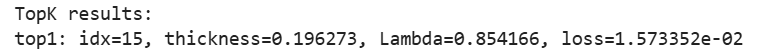

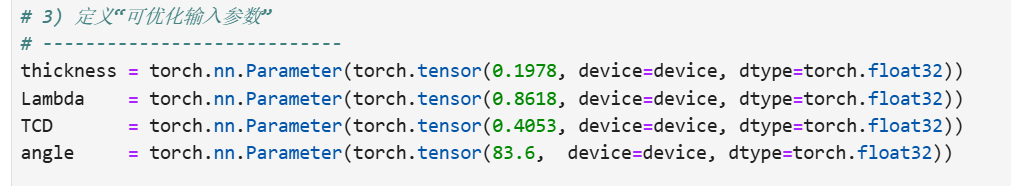

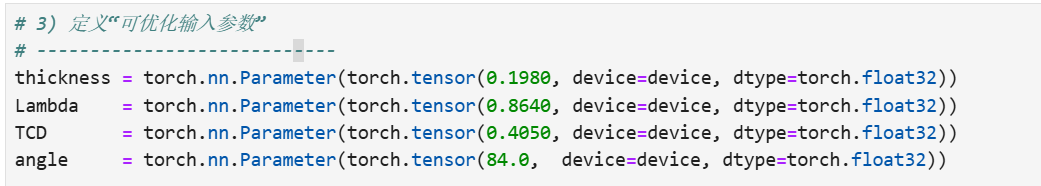

In [ ]:
# ------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.yscale("log")
plt.title("step2 loss history")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------
# 8) simple plots

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.plot(param_history[:,0]); plt.title("thickness")
plt.grid(True, alpha=0.3)

plt.subplot(1,4,2)
plt.plot(param_history[:,1]); plt.title("Lambda")
plt.grid(True, alpha=0.3)

plt.subplot(1,4,3)
plt.plot(param_history[:,2]); plt.title("TCD")
plt.grid(True, alpha=0.3)

plt.subplot(1,4,4)
plt.plot(param_history[:,4]); plt.title("angle")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()